In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import normalize, StandardScaler 
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from __future__ import print_function

In [3]:
loc = 'C:/Users/LAPTOP/Downloads/creditcards.csv'
cred_data = pd.read_csv(loc)
cred_data.sample(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
223464,143395.0,2.024433,0.281553,-1.673993,1.180634,0.756858,-0.611676,0.604127,-0.316391,-0.212609,...,0.088968,0.526617,-0.062302,-0.358147,0.514388,-0.489694,-0.009779,-0.074327,1.00,0
189751,128546.0,-3.966918,-3.967415,-1.156118,0.402303,4.238404,-1.289842,-1.598992,1.048754,-0.015504,...,0.466659,-0.239112,0.120891,-1.717099,-0.775351,-0.135447,0.178564,-0.556090,91.79,0
190515,128861.0,1.983892,-0.567330,-0.353862,0.254463,-0.536324,0.176853,-0.845894,0.122108,1.673078,...,0.016780,0.200428,0.132373,-1.080326,-0.278787,-0.347608,0.054265,-0.033886,28.46,0
66294,51976.0,-0.517092,0.597560,2.409558,1.479143,-0.143069,0.611346,-0.202836,0.258474,0.028724,...,-0.038713,0.065757,-0.318896,-0.441308,0.235446,-0.071758,0.151349,0.096407,9.99,0
234706,148075.0,2.086204,0.032427,-2.039558,0.205976,0.654481,-0.880198,0.540850,-0.308948,-0.081248,...,0.144105,0.545265,0.000515,0.842015,0.355365,0.658232,-0.122808,-0.088411,0.76,0
157211,109708.0,-0.472901,0.943151,-0.349982,-0.821776,2.332918,-1.127348,1.954733,-0.908262,0.924125,...,-0.143050,0.144859,-0.498330,0.388972,0.408467,0.477632,-0.499329,-0.257640,18.86,0
212373,138828.0,1.825687,-0.320396,-1.876158,0.642856,-0.124904,-1.453115,0.260913,-0.273841,0.912986,...,0.245230,0.522503,-0.087871,-0.131978,0.120920,-0.103083,-0.035351,-0.016526,117.90,0
114796,73623.0,0.767070,-0.944868,1.261369,1.763957,-1.090167,1.062609,-0.724059,0.275869,1.618922,...,0.005816,0.121296,-0.384144,-0.381424,0.623623,-0.196301,0.075825,0.066416,207.00,0
145439,86945.0,-0.343694,0.720691,3.746195,5.094463,-1.545430,1.666376,-0.346986,0.264082,-0.064563,...,0.176104,1.149892,-0.085483,0.968228,-0.690584,0.447159,0.014067,-0.055585,82.74,0
145875,87245.0,1.977270,-1.231201,-2.214198,-1.295488,1.522561,3.657738,-1.153180,0.877456,-0.133107,...,-0.303494,-0.482380,0.242097,0.661803,-0.177683,-0.342280,0.046190,-0.033205,76.59,0


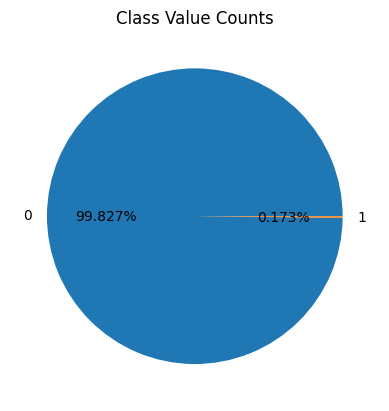

In [4]:
size = cred_data.Class.value_counts()
labels = size.index
size = size.values
fig, ax = plt.subplots()
ax.pie(size, labels=labels, autopct='%1.3f%%')
ax.set_title('Class Value Counts')
plt.show()

<Axes: >

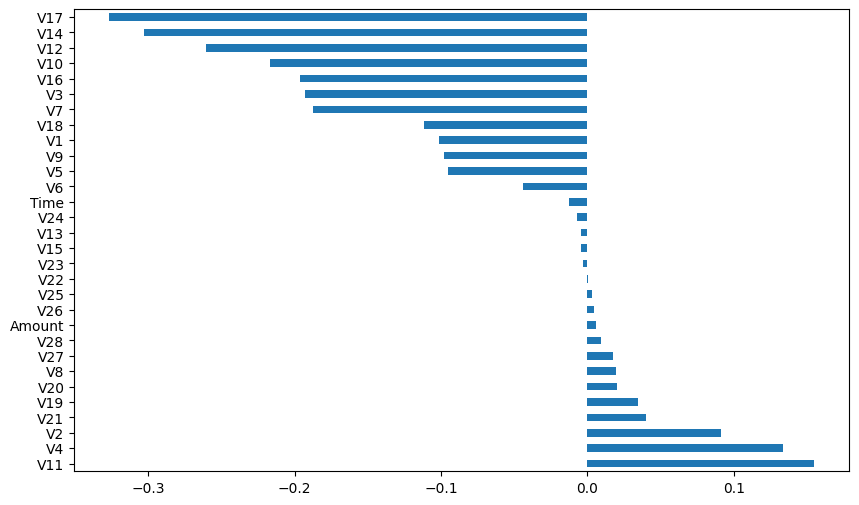

In [43]:
correlation = cred_data.corr()['Class'].drop('Class').sort_values(ascending=False)
correlation.plot(kind='barh', figsize=(10,6))

In [13]:
cred_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [15]:
data_mat

array([[ 0.00000000e+00, -6.94242321e-01, -4.40749246e-02, ...,
        -6.37811507e-02,  2.44964263e-01,  0.00000000e+00],
       [ 0.00000000e+00,  6.08496328e-01,  1.61175920e-01, ...,
         4.46075177e-02, -3.42474541e-01,  0.00000000e+00],
       [ 1.00000000e+00, -6.93500463e-01, -8.11577826e-01, ...,
        -1.81020827e-01,  1.16068593e+00,  0.00000000e+00],
       ...,
       [ 1.72788000e+05,  9.80023736e-01, -1.82433725e-01, ...,
        -8.04671974e-02, -8.18393021e-02,  0.00000000e+00],
       [ 1.72788000e+05, -1.22755392e-01,  3.21250341e-01, ...,
         3.16686777e-01, -3.13248531e-01,  0.00000000e+00],
       [ 1.72792000e+05, -2.72330934e-01, -1.14898979e-01, ...,
         4.13499858e-02,  5.14355311e-01,  0.00000000e+00]],
      shape=(284807, 31))

In [16]:
cred_data.iloc[:, 1:30] = StandardScaler().fit_transform(cred_data.iloc[:, 1:30])
test = cred_data.iloc[:, 1:30].to_numpy()
data_mat = cred_data.values
vals = data_mat[:, 1:30]
targ = data_mat[:, 30]
vals = normalize(vals, norm='l1')

In [17]:
train_vals, test_vals, train_targ, test_targ = train_test_split(vals, targ, test_size=0.2, random_state=42)
train_weight = compute_sample_weight('balanced', train_targ)
tree_vet = DecisionTreeClassifier(max_depth=6, random_state=38)
tree_vet.fit(train_vals, train_targ, sample_weight=train_weight)

DecisionTreeClassifier(max_depth=6, random_state=38)

In [35]:
test = pd.DataFrame(train_weight)
test.value_counts()

0         
0.500866      227451
289.143401       394
Name: count, dtype: int64

In [44]:
svm = LinearSVC(class_weight='balanced', random_state=36,loss='hinge' ,fit_intercept=False)
svm.fit(train_vals, train_targ)

C:\Users\LAPTOP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=36)

In [41]:
pred_targ_vet = tree_vet.predict_proba(test_vals)[:,1]
pred_targ_vet

array([0.99312981, 0.04201658, 0.04201658, ..., 0.04201658, 0.04201658,
       0.04201658], shape=(56962,))

In [42]:
roc_auc_vet = roc_auc_score(test_targ, pred_targ_vet)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_vet))

Decision Tree ROC-AUC score : 0.902


In [50]:
pred_targ_svm = svm.decision_function(test_vals)
pred_targ_svm

array([27.86523527, -0.4950112 , -1.0351294 , ..., -0.53887437,
       -1.31297912,  4.19133486], shape=(56962,))

In [51]:
roc_auc_svm = roc_auc_score(test_targ, pred_targ_svm)
print('SVM ROC-AUC score : {0:.3f}'.format(roc_auc_svm))

SVM ROC-AUC score : 0.984
